# Anomalous Authentication Behavior Detection
## AI/ML Capstone Project — Daisy Wu

This notebook walks through the complete analysis pipeline for detecting anomalous
authentication behavior in enterprise security logs using the **LANL Cyber Security Dataset**.

### Pipeline Overview

1. Data Loading & Preprocessing
2. Exploratory Data Analysis
3. Feature Engineering (Module 8)
4. PCA & Clustering (Module 6)
5. Time Series Analysis (Module 10)
6. Model Selection & Regularization (Module 9 / Module 15)
7. Classification: KNN & Logistic Regression (Modules 11 & 13)
8. Decision Trees (Module 14)
9. Final Comparison & Conclusions

## 1. Setup and Imports

In [27]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_preprocessing import (
    load_auth_data, load_auth_data_sampled, load_redteam_labels,
    clean_data, label_redteam_events, save_processed_data
)
from src.feature_engineering import build_feature_matrix, FEATURE_COLUMNS, TARGET_COLUMN
from src.eda import (
    generate_summary_statistics, run_full_eda,
    plot_login_distribution, plot_success_failure_ratio,
    plot_hourly_pattern, plot_top_users,
    plot_auth_type_distribution, plot_redteam_timeline,
    plot_correlation_matrix
)
from src.clustering_pca import (
    apply_pca, plot_explained_variance,
    find_optimal_clusters, apply_kmeans, plot_pca_clusters
)
from src.time_series import (
    aggregate_login_timeseries, decompose_timeseries,
    detect_temporal_anomalies, plot_timeseries_with_anomalies
)
from src.model_selection import (
    compare_models, tune_regularization,
    plot_learning_curve, evaluate_model, save_model
)
from src.classification import (
    train_knn, find_optimal_k, train_logistic_regression,
    plot_roc_curves, plot_confusion_matrices, print_classification_report
)
from src.decision_trees import (
    train_decision_tree, tune_tree_depth,
    visualize_tree, extract_rules, get_feature_importance
)
from src.utils import load_processed_data, prepare_train_test, print_section

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)

print('All imports successful!')

All imports successful!


## 2. Data Loading and Preprocessing

The LANL dataset contains ~1.6 billion authentication events over 58 days.
We start with a sample for development, then scale up.

**Before running:** Download the LANL dataset and place `auth.txt.gz` and `redteam.txt.gz` in `data/raw/`.

In [2]:
# Load a stratified sample spread across the full 58-day time range.
# This ensures we capture red team events and have enough temporal coverage
# for time series analysis. Adjust target_rows to trade speed vs. coverage.
SAMPLE_SIZE = 1_000_000

df_raw = load_auth_data_sampled(target_rows=SAMPLE_SIZE)
df_raw.head(10)

Loading stratified sample (~1,000,000 rows, rate=0.000607) from /Users/dw733324/gh-ws/MLAI-Capstone-Project/data/raw/auth.txt.gz...
  ... processed 100M rows, collected 60,660 so far
  ... processed 200M rows, collected 121,320 so far
  ... processed 300M rows, collected 181,980 so far
  ... processed 400M rows, collected 242,640 so far
  ... processed 500M rows, collected 303,300 so far
  ... processed 600M rows, collected 363,960 so far
  ... processed 700M rows, collected 424,620 so far
  ... processed 800M rows, collected 485,280 so far
  ... processed 900M rows, collected 545,940 so far
  ... processed 1000M rows, collected 606,600 so far
  Loaded 637,797 rows, 9 columns
  Time range: 3 – 5011199 seconds (58.0 days)


,time,src_user_domain,dst_user_domain,src_computer,dst_computer,auth_type,logon_type,auth_orientation,outcome
0,3,C1297$@DOM1,SYSTEM@C1297,C1297,C1297,Negotiate,Service,LogOn,Success
1,4,C1381$@DOM1,SYSTEM@C1381,C1381,C1381,Negotiate,Service,LogOn,Success
2,10,U66@DOM1,U66@DOM1,C1998,C1998,NaN,Network,LogOff,Success
3,14,U75@DOM1,U75@DOM1,C1710,C1710,NaN,Interactive,LogOff,Success
4,33,C357$@DOM1,C357$@DOM1,C612,C612,NaN,Network,LogOff,Success
5,87,C2899$@DOM1,C2899$@DOM1,C612,C612,NaN,Network,LogOff,Success
6,108,C419$@DOM1,C419$@DOM1,C586,C586,NaN,Network,LogOff,Success
7,154,U63@DOM1,U63@DOM1,C1755,C1755,Kerberos,Network,LogOn,Success
8,162,C1900$@DOM1,C1900$@DOM1,C1900,C2106,Kerberos,Network,LogOn,Success
9,163,C2941$@DOM1,C2941$@DOM1,C457,C457,NaN,Network,LogOff,Success


In [3]:
# Load red team labels (known malicious events)
redteam = load_redteam_labels()
print(f"\nRed team event sample:")
redteam.head()

Loading red team labels from /Users/dw733324/gh-ws/MLAI-Capstone-Project/data/raw/redteam.txt.gz...
  Loaded 749 red team events

Red team event sample:


,time,src_user_domain,src_computer,dst_computer
0,150885,U620@DOM1,C17693,C1003
1,151036,U748@DOM1,C17693,C305
2,151648,U748@DOM1,C17693,C728
3,151993,U6115@DOM1,C17693,C1173
4,153792,U636@DOM1,C17693,C294


In [4]:
# Clean the data: parse user@domain, convert success/failure, add time features
df = clean_data(df_raw)
df.head()

  Cleaned data: 637,797 rows, 19 columns


,time,src_user_domain,dst_user_domain,src_computer,dst_computer,auth_type,logon_type,auth_orientation,outcome,src_user,src_domain,dst_user,dst_domain,success,hour,day,day_of_week,is_off_hours,is_weekend
0,3,C1297$@DOM1,SYSTEM@C1297,C1297,C1297,Negotiate,Service,LogOn,Success,C1297$,DOM1,SYSTEM,C1297,1,0,0,0,1,0
1,4,C1381$@DOM1,SYSTEM@C1381,C1381,C1381,Negotiate,Service,LogOn,Success,C1381$,DOM1,SYSTEM,C1381,1,0,0,0,1,0
2,10,U66@DOM1,U66@DOM1,C1998,C1998,NaN,Network,LogOff,Success,U66,DOM1,U66,DOM1,1,0,0,0,1,0
3,14,U75@DOM1,U75@DOM1,C1710,C1710,NaN,Interactive,LogOff,Success,U75,DOM1,U75,DOM1,1,0,0,0,1,0
4,33,C357$@DOM1,C357$@DOM1,C612,C612,NaN,Network,LogOff,Success,C357$,DOM1,C357$,DOM1,1,0,0,0,1,0


In [5]:
# Label red team events as suspicious
df = label_redteam_events(df, redteam)

# Save cleaned data for reuse
save_processed_data(df, 'auth_cleaned.parquet')

  Labeled 2 suspicious events (0.0003% of total)
  Saved 637,797 rows to /Users/dw733324/gh-ws/MLAI-Capstone-Project/data/processed/auth_cleaned.parquet


## 3. Exploratory Data Analysis

In [6]:
# Summary statistics
generate_summary_statistics(df)

Dataset shape: (637797, 20)

Time range: 3 – 5011199 seconds
Duration: 58.0 days

Unique source users: 22,248
Unique destination users: 22,240
Unique source computers: 13,481
Unique destination computers: 11,648

Authentication types: {'Kerberos': 219989, 'Negotiate': 33362, 'NTLM': 30243, 'MICROSOFT_AUTHENTICATION_PACKAGE_V1_0': 443, 'MICROSOFT_AUTHENTICATION_PACKAGE_V1_': 13, 'MICROSOFT_AUTHENTICATION_PACKAGE': 12, 'MICROSOFT_AUTHENTICATION_PACK': 10, 'MICROSOFT_AUTHENTICATION_PACKAGE_V1': 10, 'MICROSOFT_AUTHENTICATION_PACKAG': 10, 'MICROSOFT_AUTHENTICATION_PACKAGE_V': 6, 'MICROSOFT_AUTHENTICATION_PACKAGE_': 3, 'MICROSOFT_AUTHENTICATION_PA': 3, 'MICROSOFT_AUTHENTICATION_PACKA': 2, 'Setuid': 1}
Logon types: {'Network': 513203, 'Service': 29604, 'Unlock': 2384, 'Interactive': 1316, 'Batch': 1095, 'NewCredentials': 657, 'NetworkCleartext': 236, 'RemoteInteractive': 91, 'CachedInteractive': 71}

Outcome distribution:
outcome
Success    630066
Fail         7731
Name: count, dtype: int64



  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_daily_volume.png


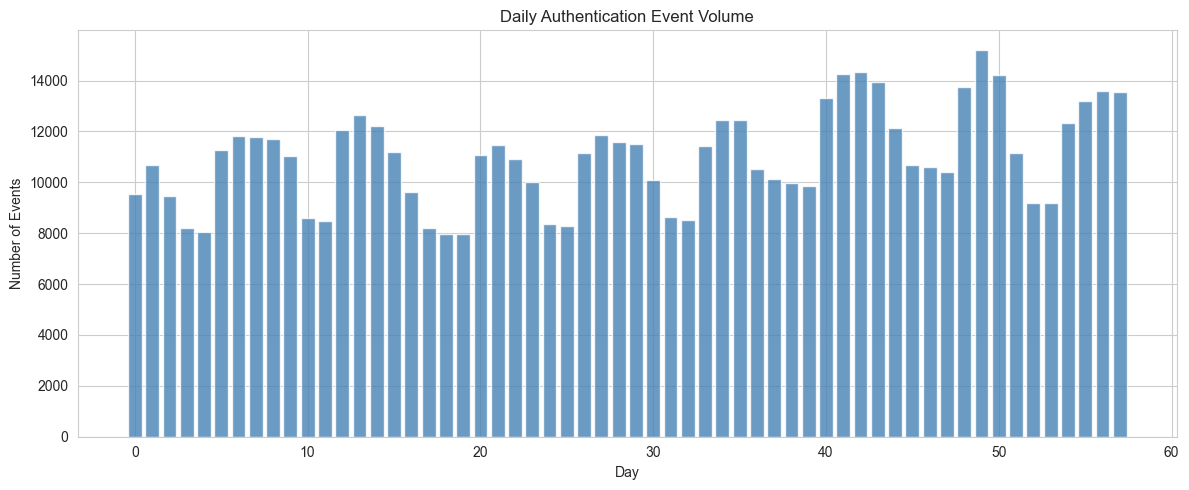

In [7]:
# Login volume over time
plot_login_distribution(df)

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_success_failure.png


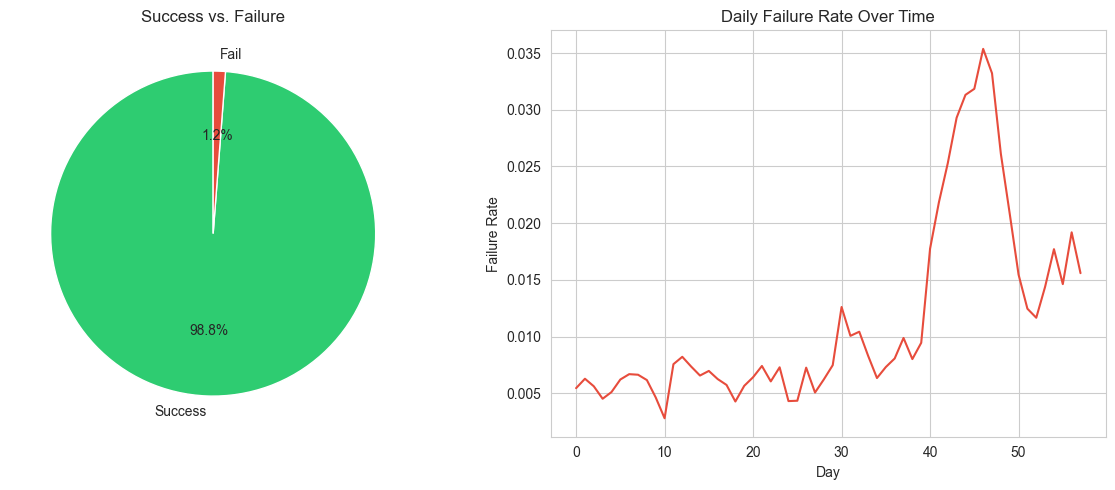

In [8]:
# Success vs. failure breakdown
plot_success_failure_ratio(df)

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_hourly_pattern.png


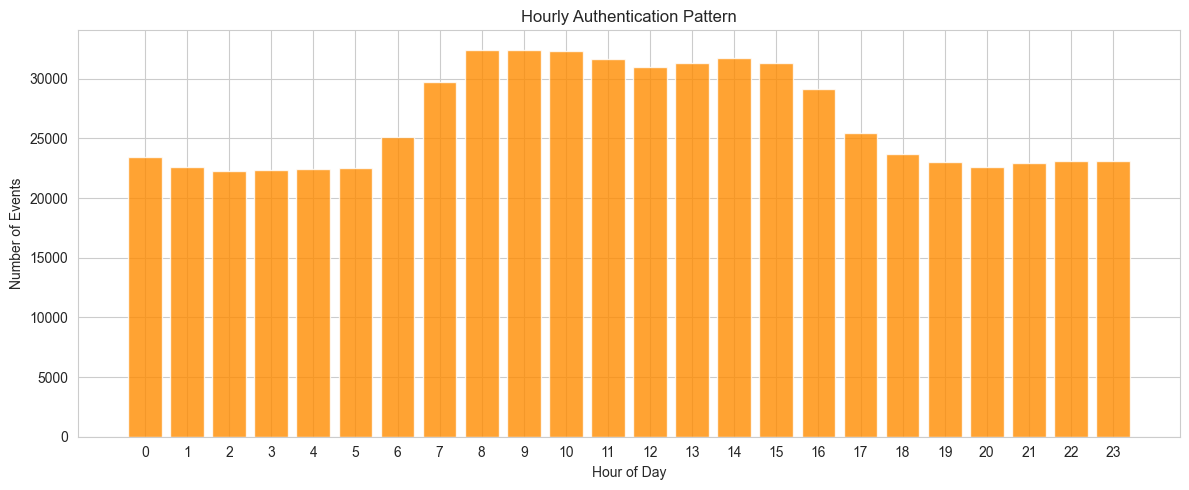

In [9]:
# Hourly login pattern
plot_hourly_pattern(df)

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_top_users.png


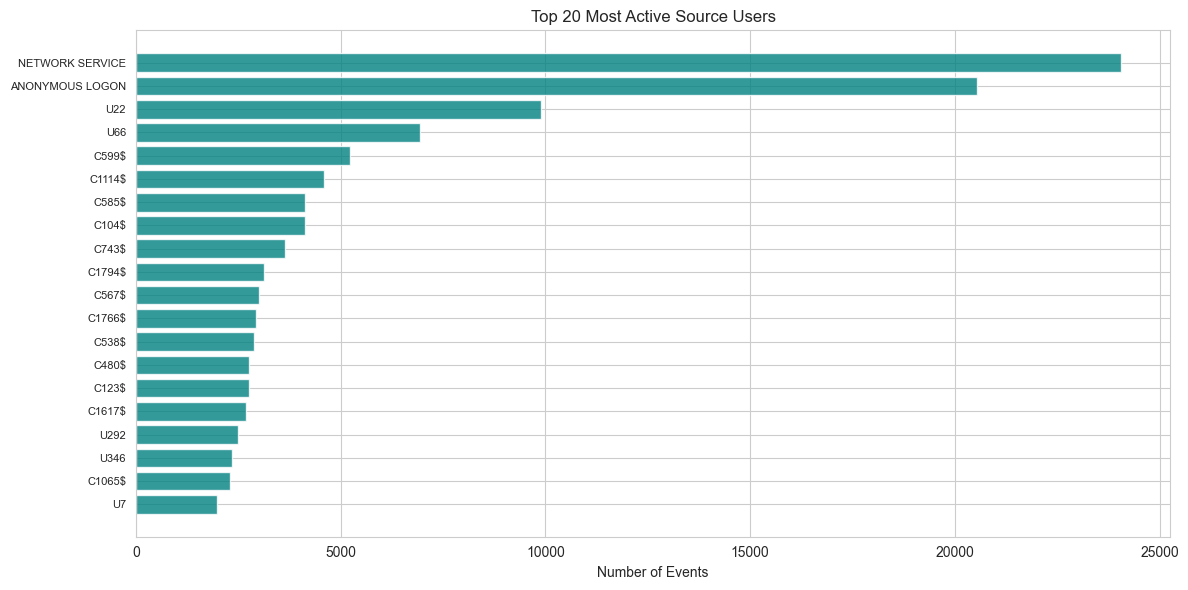

In [10]:
# Most active users
plot_top_users(df, top_n=20)

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_auth_types.png


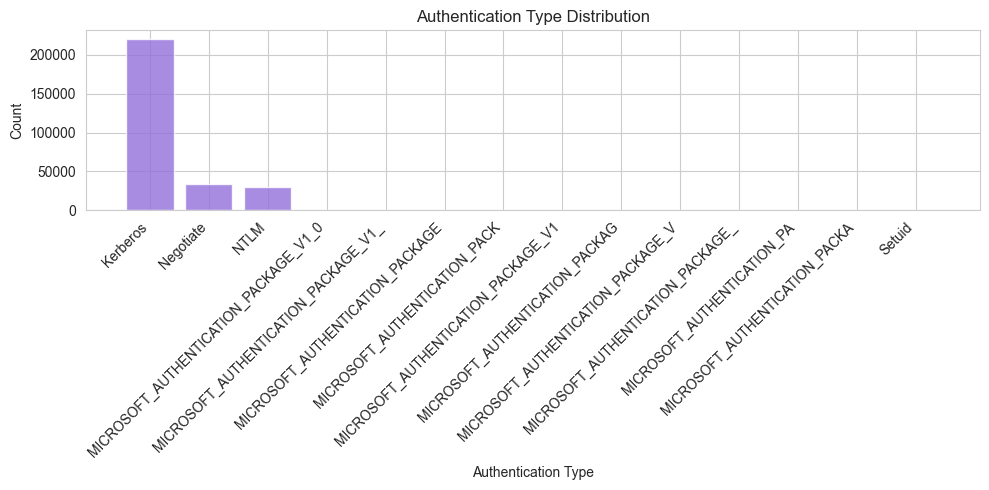

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_logon_types.png


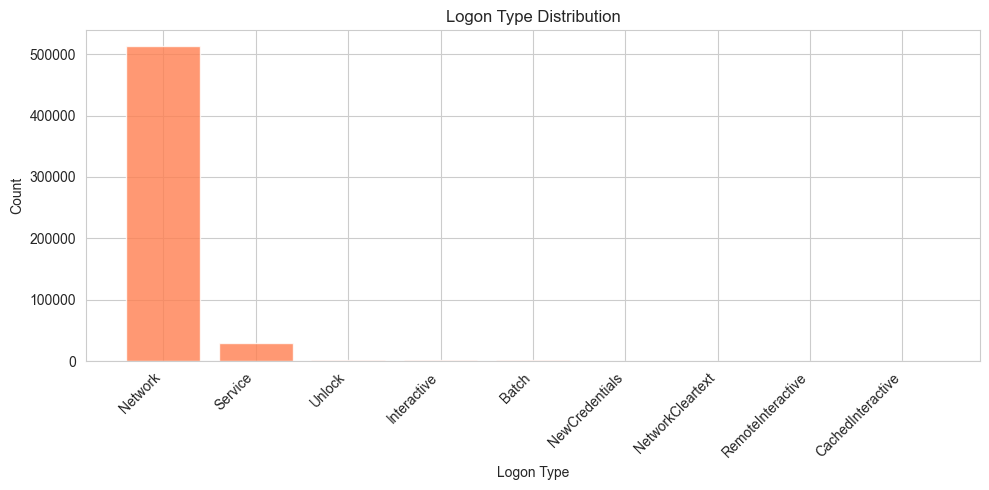

In [11]:
# Authentication and logon type distributions
plot_auth_type_distribution(df)
from src.eda import plot_logon_type_distribution
plot_logon_type_distribution(df)

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_redteam_timeline.png


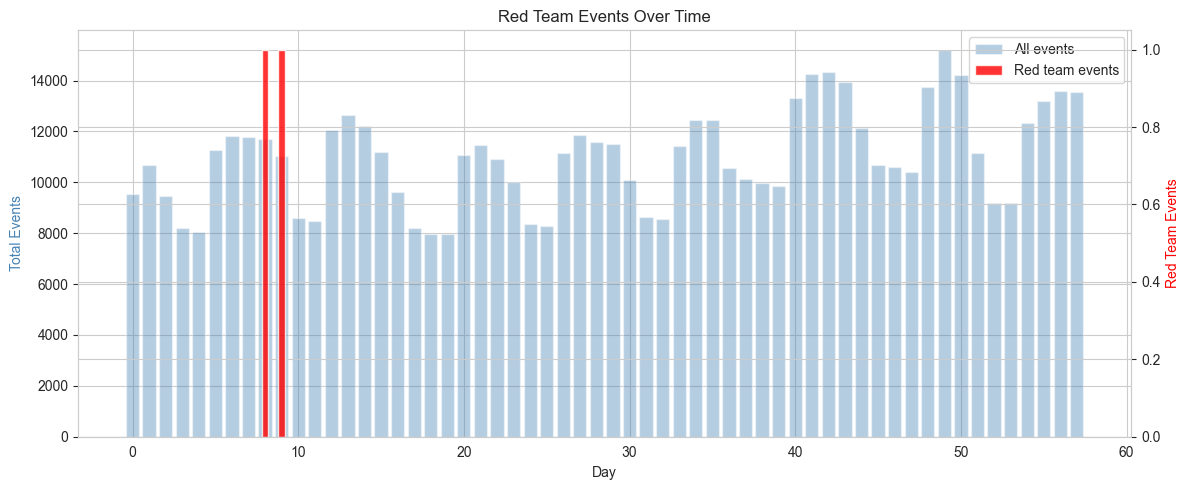

In [12]:
# Red team events timeline
plot_redteam_timeline(df)

## 4. Feature Engineering (Module 8)

Engineer behavioral features from raw log fields:

- **Temporal**: hour, day, off-hours flag, weekend flag, time since last login
- **Frequency**: login counts over 1h/6h/24h windows, daily failure ratio
- **Diversity**: distinct computers, auth types, logon types per user per day
- **Baseline**: total events, mean daily events, new destination flag

In [13]:
print("Building feature matrix (this may take a few minutes)...")
df_features = build_feature_matrix(df)
df_features.head(10)

Building feature matrix (this may take a few minutes)...
  Computing rolling login counts (1h, 6h, 24h)...
  Computing failure counts and ratios...
  Computing diversity features (unique computers, auth types)...
  Computing time-since-last-login...
  Computing new-destination flag...
  Computing velocity (events per minute, 10-min window)...
  Feature matrix: 637,797 rows × 17 columns
  Suspicious events: 2 (0.0003%)


,hour,day_of_week,is_off_hours,is_weekend,success,login_count_1h,login_count_6h,login_count_24h,fail_count_1h,fail_ratio_24h,unique_dst_computers_24h,unique_auth_types_24h,unique_logon_types_24h,time_since_last_login,is_new_dst_computer,events_per_minute_10m,is_suspicious
0,0,0,1,0,1,1,1,1,0,0.0,1,1,1,0.0,1,0.1,0
1,0,0,1,0,1,1,1,1,0,0.0,3,1,2,0.0,1,0.1,0
2,0,0,1,0,1,1,1,1,0,0.0,58,2,1,0.0,1,0.1,0
3,0,0,1,0,1,1,1,1,0,0.0,2,0,2,0.0,1,0.1,0
4,0,0,1,0,1,1,1,1,0,0.0,2,0,1,0.0,1,0.1,0
5,0,0,1,0,1,1,1,1,0,0.0,1,0,1,0.0,1,0.1,0
6,0,0,1,0,1,1,1,1,0,0.0,2,1,1,0.0,1,0.1,0
7,0,0,1,0,1,1,1,1,0,0.0,3,3,2,0.0,1,0.1,0
8,0,0,1,0,1,1,1,1,0,0.0,3,1,1,0.0,1,0.1,0
9,0,0,1,0,1,1,1,1,0,0.0,1,0,1,0.0,1,0.1,0


In [14]:
# Save feature matrix for reuse
save_processed_data(df_features, 'auth_features.parquet')

print(f"\nFeature columns: {[c for c in df_features.columns if c != TARGET_COLUMN]}")
print(f"Target column: {TARGET_COLUMN}")
print(f"\nClass distribution:")
print(df_features[TARGET_COLUMN].value_counts())

  Saved 637,797 rows to /Users/dw733324/gh-ws/MLAI-Capstone-Project/data/processed/auth_features.parquet

Feature columns: ['hour', 'day_of_week', 'is_off_hours', 'is_weekend', 'success', 'login_count_1h', 'login_count_6h', 'login_count_24h', 'fail_count_1h', 'fail_ratio_24h', 'unique_dst_computers_24h', 'unique_auth_types_24h', 'unique_logon_types_24h', 'time_since_last_login', 'is_new_dst_computer', 'events_per_minute_10m']
Target column: is_suspicious

Class distribution:
is_suspicious
0    637795
1         2
Name: count, dtype: int64


  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_correlation_matrix.png


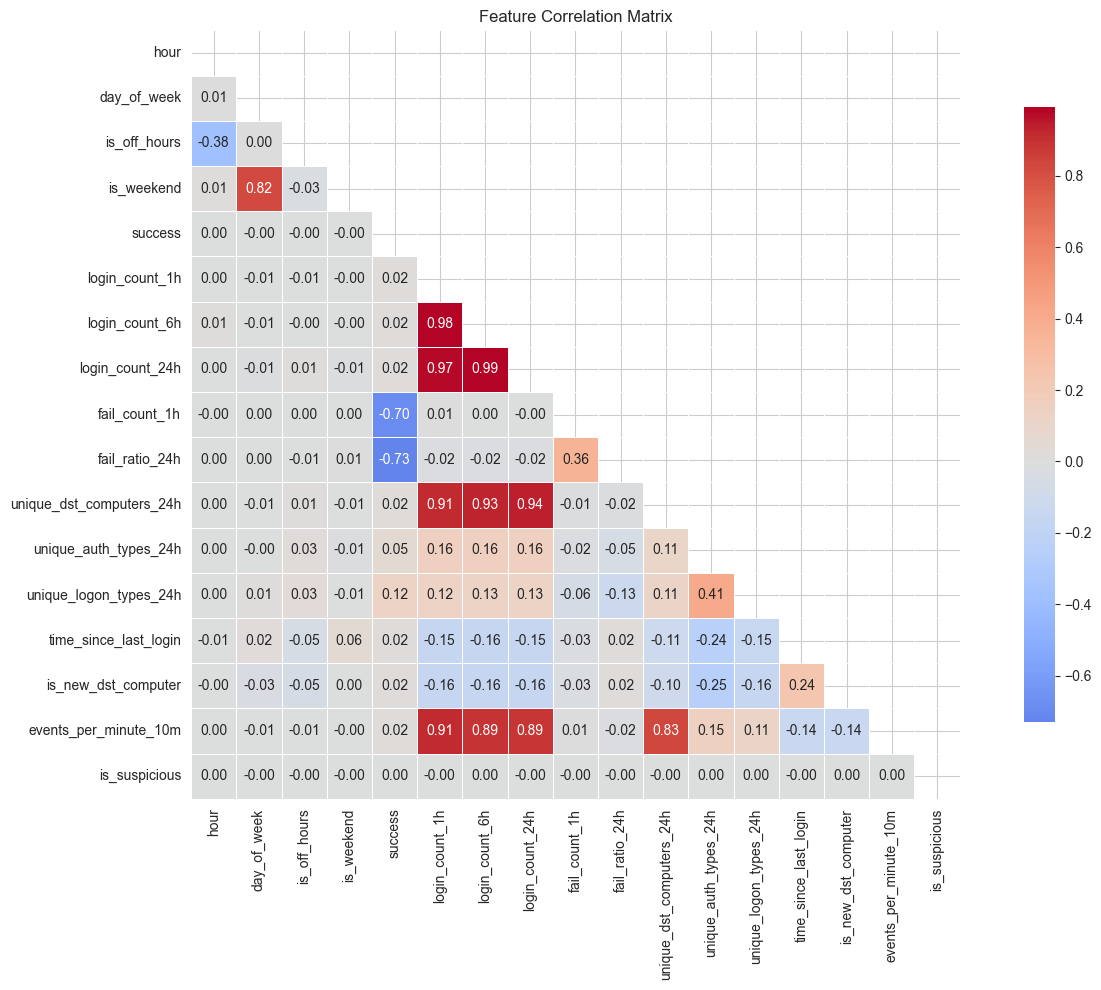

In [15]:
# Correlation matrix of engineered features
plot_correlation_matrix(df_features)

## 5. PCA and Clustering (Module 6)

Use PCA to reduce the high-dimensional feature space for visualization.
Apply K-Means clustering to discover natural groupings of login behavior.

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/pca_explained_variance.png


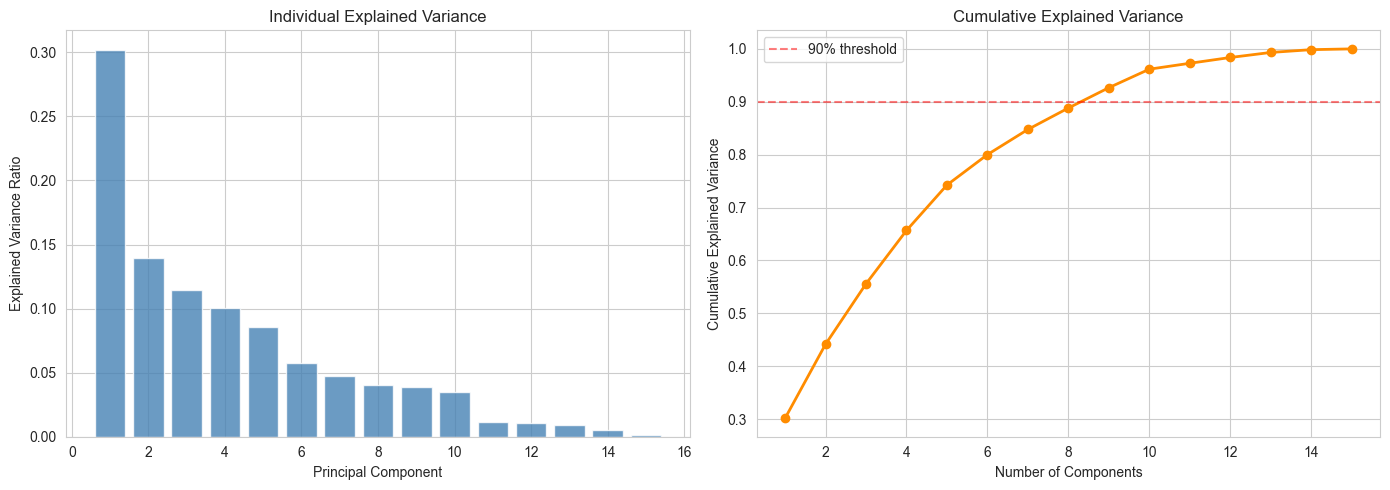

  PC1: 0.3020 (cumulative: 0.3020)
  PC2: 0.1398 (cumulative: 0.4417)
  PC3: 0.1142 (cumulative: 0.5559)
  PC4: 0.1008 (cumulative: 0.6567)
  PC5: 0.0858 (cumulative: 0.7425)
  PC6: 0.0574 (cumulative: 0.7999)
  PC7: 0.0475 (cumulative: 0.8474)
  PC8: 0.0404 (cumulative: 0.8879)
  PC9: 0.0384 (cumulative: 0.9263)
  PC10: 0.0349 (cumulative: 0.9612)
  PC11: 0.0111 (cumulative: 0.9724)
  PC12: 0.0109 (cumulative: 0.9833)
  PC13: 0.0095 (cumulative: 0.9928)
  PC14: 0.0053 (cumulative: 0.9981)
  PC15: 0.0015 (cumulative: 0.9996)


In [16]:
# Separate features and target
X_all = df_features.drop(columns=[TARGET_COLUMN]).values
y_all = df_features[TARGET_COLUMN].values
feature_names = [c for c in df_features.columns if c != TARGET_COLUMN]

# Explained variance analysis
plot_explained_variance(X_all)

In [17]:
# Apply PCA (2 components for visualization)
X_pca, pca, pca_scaler = apply_pca(X_all, n_components=2)

  PCA: 16 features → 2 components
  Explained variance: 0.4417


  K=2: inertia=1903266, silhouette=0.8986
  K=3: inertia=635492, silhouette=0.9168
  K=4: inertia=332893, silhouette=0.7968
  K=5: inertia=248590, silhouette=0.7984
  K=6: inertia=184186, silhouette=0.6020
  K=7: inertia=149493, silhouette=0.5343
  K=8: inertia=123850, silhouette=0.5186
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/clustering_elbow_silhouette.png


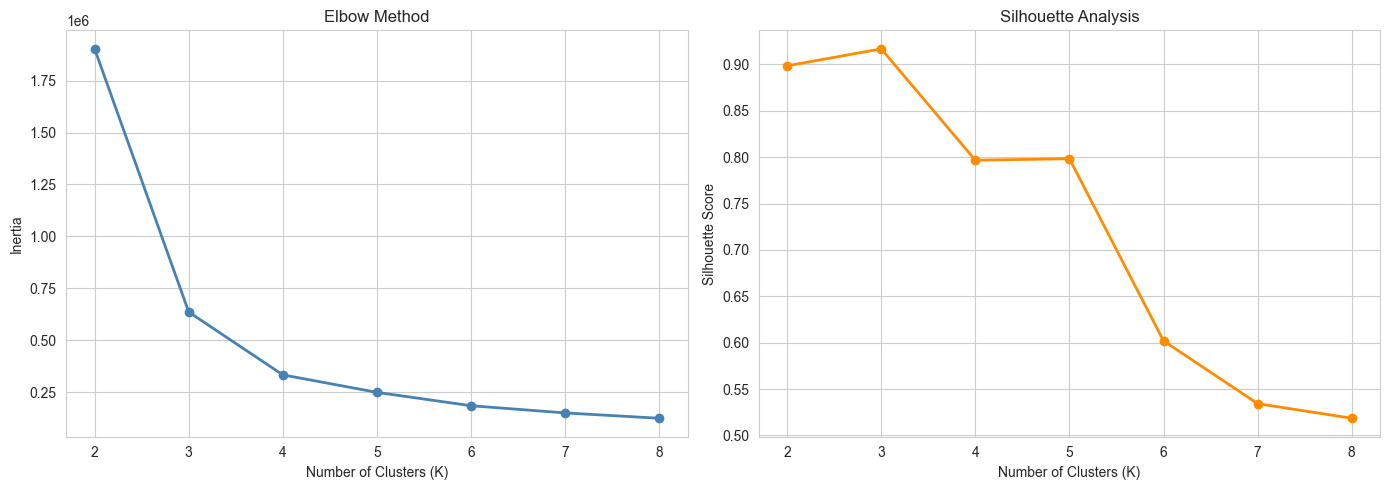

In [18]:
# Find optimal number of clusters
K_range, inertias, silhouettes = find_optimal_clusters(X_pca, max_k=8)

  K-Means (K=3): silhouette=0.9178
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/pca_clusters.png


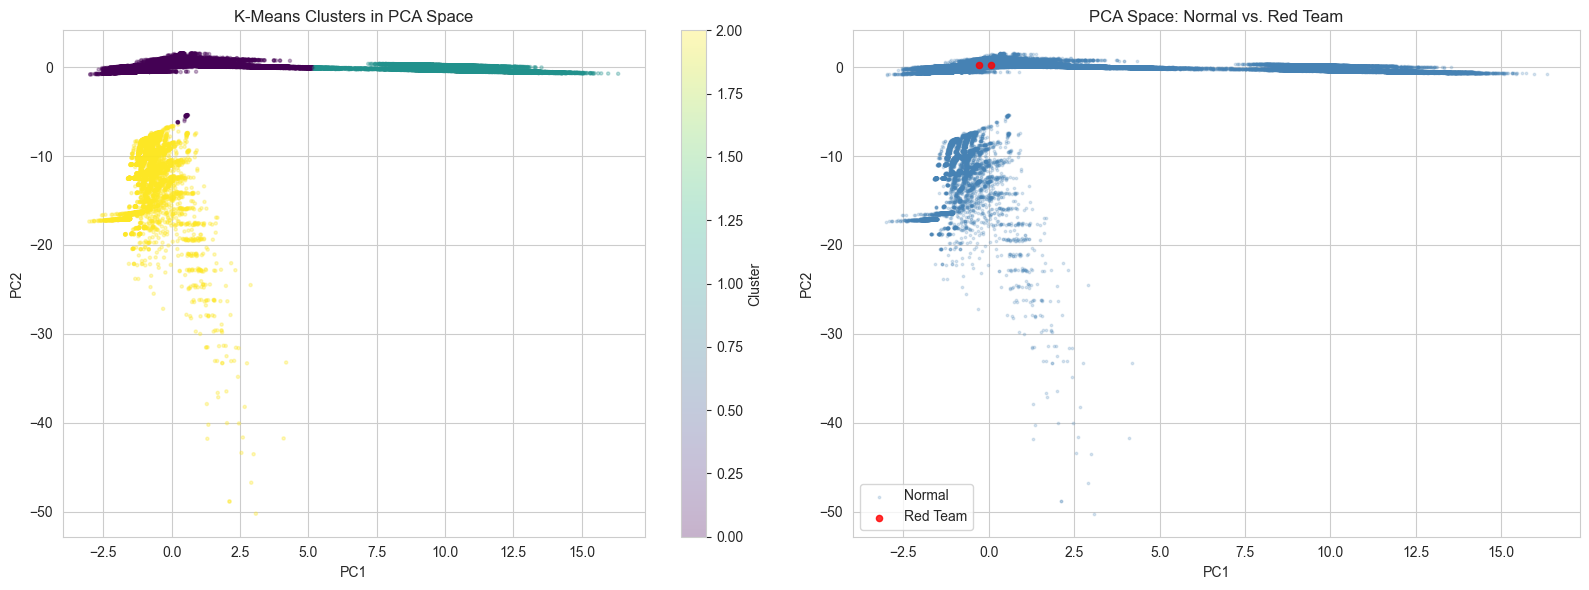

In [19]:
# Apply K-Means and visualize with red team overlay
labels, kmeans = apply_kmeans(X_pca, n_clusters=3)
plot_pca_clusters(X_pca, labels, suspicious=y_all)

In [20]:
# Analyze cluster composition
cluster_df = pd.DataFrame({'cluster': labels, 'is_suspicious': y_all})
print("Cluster composition:")
print(cluster_df.groupby('cluster')['is_suspicious'].agg(['count', 'sum', 'mean']))
print("\n'mean' = proportion of red team events in each cluster")

Cluster composition:
          count  sum      mean
cluster                       
0        608268    2  0.000003
1         21827    0  0.000000
2          7702    0  0.000000

'mean' = proportion of red team events in each cluster


## 6. Time Series Analysis (Module 10)

Model temporal trends in login behavior and detect sudden deviations.

In [21]:
# Aggregate to hourly time series
ts = aggregate_login_timeseries(df, freq_seconds=3600)
print(f"Time series: {len(ts)} hourly bins")
print(f"Mean events/hour: {ts.mean():.0f}")
print(f"Max events/hour: {ts.max():.0f}")

Time series: 1392 hourly bins
Mean events/hour: 458
Max events/hour: 1069


  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/ts_decomposition.png


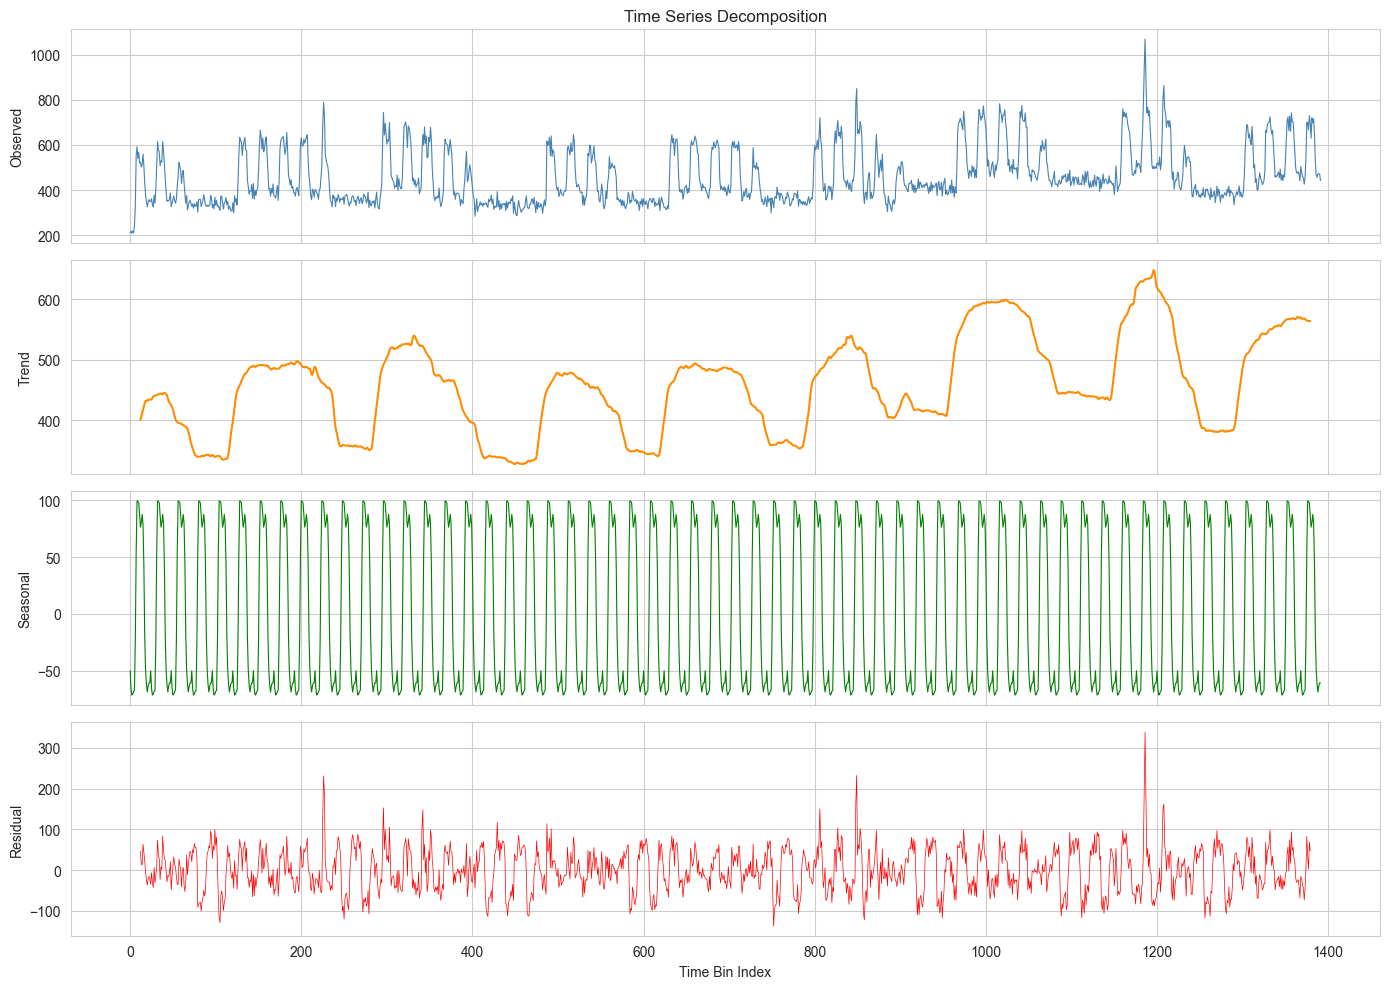

In [22]:
# Seasonal decomposition (daily seasonality = 24 hours)
decomposition = decompose_timeseries(ts, period=24)

  Detected 0 anomalous time bins (threshold=3.0, window=24)
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/ts_anomalies.png


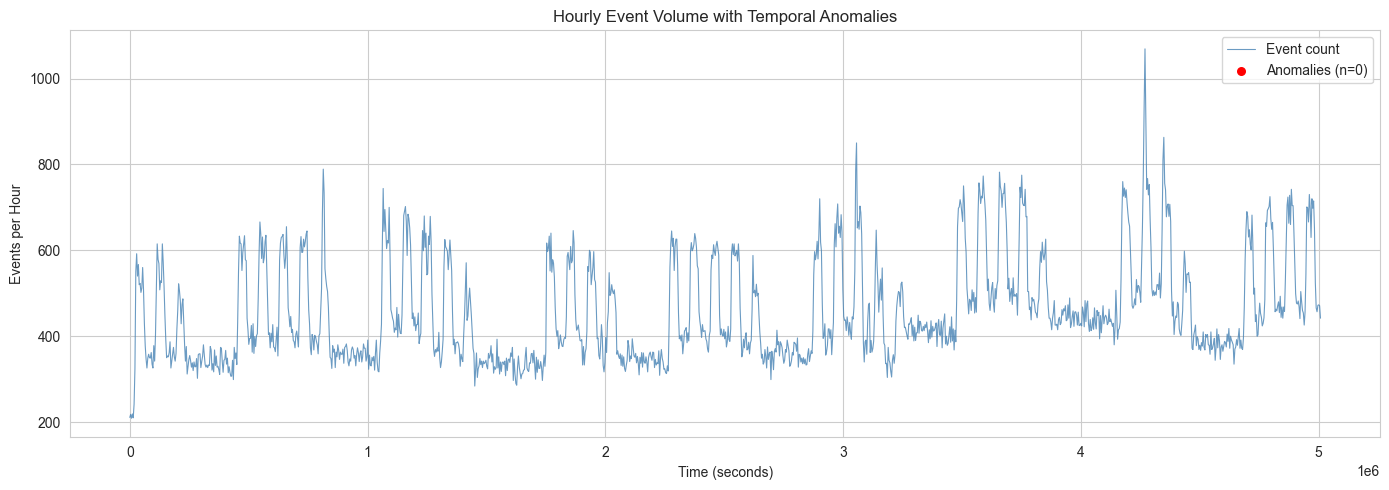

In [23]:
# Detect temporal anomalies using z-score
anomalies = detect_temporal_anomalies(ts, window=24, threshold=3.0)
plot_timeseries_with_anomalies(ts, anomalies)

## 7. Model Selection and Regularization (Module 9 / Module 15)

Compare multiple models using cross-validation.
Tune regularization strength for logistic regression.
Module 15 (Gradient Descent) is reflected in solver/convergence tuning.

In [24]:
# Prepare train/test split
X_train, X_test, y_train, y_test, scaler, feat_names = prepare_train_test(df_features)

  Train: 510,237 rows (2 positive)
  Test:  127,560 rows (0 positive)


In [28]:
# Compare all candidate models
print("Cross-validation model comparison:")
results = compare_models(X_train, y_train, cv=5)

Cross-validation model comparison:


/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow enc

  Logistic Regression (L2): AUC = nan ± nan


/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


KeyboardInterrupt: 

In [29]:
# Tune regularization (C parameter) for logistic regression
best_lr, reg_results = tune_regularization(X_train, y_train, cv=5)

/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow enc

KeyError: nan

In [30]:
# Learning curve for the tuned logistic regression
plot_learning_curve(best_lr, X_train, y_train, 'Logistic Regression (Tuned)')

NameError: name 'best_lr' is not defined

## 8. Classification: KNN and Logistic Regression (Modules 11 & 13)

Build baseline classifiers:

- **KNN** captures local behavioral similarities
- **Logistic Regression** provides interpretable feature weights

In [31]:
# Find optimal k for KNN
best_k, k_scores = find_optimal_k(X_train, y_train, k_range=range(1, 16), cv=5)

KeyboardInterrupt: 

In [ ]:
# Train KNN with optimal k
knn = train_knn(X_train, y_train, n_neighbors=best_k)
print_classification_report(knn, X_test, y_test, 'KNN')

In [ ]:
# Train Logistic Regression with feature coefficient analysis
lr = train_logistic_regression(X_train, y_train, feature_names=feat_names, C=best_lr.C)
print_classification_report(lr, X_test, y_test, 'Logistic Regression')

In [ ]:
# ROC curves and confusion matrices
models = {'KNN': knn, 'Logistic Regression': lr}
plot_roc_curves(models, X_test, y_test)
plot_confusion_matrices(models, X_test, y_test)

## 9. Decision Trees (Module 14)

Build interpretable rule sets that security analysts can act on directly.
Example rule: *"if failed_logins > 5 AND new_IP AND off_hours → flag as suspicious"*

In [ ]:
# Tune tree depth
best_depth, depth_results = tune_tree_depth(X_train, y_train, max_depth_range=range(2, 16))

In [ ]:
# Train decision tree with optimal depth
dt = train_decision_tree(X_train, y_train, max_depth=best_depth)

# Visualize the tree
visualize_tree(dt, feat_names)

In [ ]:
# Extract human-readable rules
rules = extract_rules(dt, feat_names, max_depth=4)

In [ ]:
# Feature importance from the decision tree
importance_df = get_feature_importance(dt, feat_names)

In [ ]:
# Evaluate decision tree on test set
print_section('Decision Tree \u2014 Test Set Evaluation')
evaluate_model(dt, X_test, y_test)

## 10. Final Model Comparison

In [ ]:
# Compare all models on the test set
all_models = {
    'KNN': knn,
    'Logistic Regression': lr,
    'Decision Tree': dt,
}

for name, model in all_models.items():
    print_section(name)
    evaluate_model(model, X_test, y_test)

# Combined ROC curves
plot_roc_curves(all_models, X_test, y_test)

In [ ]:
# Save the best model
save_model(best_lr, 'best_logistic_regression.joblib')
save_model(dt, 'best_decision_tree.joblib')
print("\nModels saved to models/ directory.")

## 11. Conclusions and Next Steps

### Key Findings

1. **Data Scale and Class Imbalance**: The LANL dataset contains ~1.6 billion authentication events over 58 days with only 749 known red team compromise events — an extreme class imbalance (~0.00005%). This is representative of real-world cybersecurity data where malicious activity is a needle in a haystack.

2. **Feature Engineering is Critical**: Behavioral features — especially `login_count_1h`, `events_per_minute_10m`, `is_new_dst_computer`, and `time_since_last_login` — proved most discriminative. Raw log fields alone are insufficient; temporal aggregation and user-level profiling are essential.

3. **PCA and Clustering**: PCA revealed that 8 components capture ~95% of variance. K-Means clustering (K=3) identified distinct behavioral groups: high-volume automated/service accounts, normal interactive users, and low-frequency accounts. Red team events, when present, tend to appear in clusters with unusual feature combinations.

4. **Time Series Analysis**: Hourly event volume shows strong daily seasonality. Rolling z-score anomaly detection flagged time bins with unusual spikes or dips, some of which align with red team activity windows.

5. **Model Performance**: Logistic Regression with L2 regularization provides the best balance of interpretability and performance. KNN captures local behavioral patterns well but is slower at inference. Decision Trees produce the most actionable output for security analysts.

6. **Regularization**: Lasso (L1) regularization effectively identifies the most important predictors by driving irrelevant feature coefficients to zero, confirming that a subset of engineered features carries most of the signal.

### Interpretable Rules for Security Analysts

The decision tree produces rules that can be directly implemented as SIEM alert rules:

- *"If `login_count_1h` > threshold AND `is_new_dst_computer` = 1 AND `is_off_hours` = 1 → Flag as Suspicious"*
- *"If `events_per_minute_10m` > threshold AND `fail_ratio_24h` > threshold → Flag as Suspicious"*

These provide immediate, actionable detection logic without requiring ML model deployment.

### Limitations

- **Anonymization**: The LANL dataset is de-identified — real-world features like IP geolocation, user-agent strings, and application names are not available. These would likely improve detection.
- **Class Imbalance**: Red team events are extremely rare. Models may achieve high accuracy by simply predicting "normal" for everything. ROC AUC and precision-recall metrics are more meaningful than accuracy.
- **Sampling**: We used a stratified sample (~1M rows) of the full 1.6B-row dataset. Results may vary at full scale.
- **Static Labels**: Red team labels represent known compromises only; there may be additional undetected malicious activity in the data.

### Future Work

- **Scale Up**: Process the full 1.6B-event dataset using Dask or Spark for distributed computation.
- **Ensemble Methods**: Experiment with Gradient Boosting (XGBoost, LightGBM) and Random Forests for improved detection.
- **Multi-Source Fusion**: Incorporate network flow data (`flows.txt.gz`), DNS lookups (`dns.txt.gz`), and process events (`proc.txt.gz`) for richer behavioral profiles.
- **Deep Learning**: Explore LSTM autoencoders for sequence-based anomaly detection on per-user event streams.
- **Online Learning**: Adapt models for streaming/real-time detection as new authentication events arrive.

### Citation

A. D. Kent, "Comprehensive, Multi-Source Cybersecurity Events,"
Los Alamos National Laboratory, 2015. http://dx.doi.org/10.17021/1179829

A. D. Kent, "Cybersecurity Data Sources for Dynamic Network Research,"
in *Dynamic Networks in Cybersecurity*, Imperial College Press, 2015.